###5.3.1 특성 추출 기법

In [6]:
#필요한 라이브러리 설치
!pip install opencv-python

↪ OpenCV
- Open Source Computer Vision Library의 약어
- 오픈 소스 컴퓨터 비전 라이브러리

In [7]:
#라이브러리 호출
import os
import time
import copy
import glob
import cv2    #앞에서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision    #컴퓨터 비전 용도의 패키지
import torchvision.transforms as transforms   #데이터 전처리 위해 사용되는 패키지
import torchvision.models as models     #다양한 파이토치 네트워크 사용할 수 있도록 하는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np


In [8]:
#이미지 데이터 전처리 방법 정의
data_path = '/content/drive/MyDrive/Euron_9기DL/data/catanddog/train'    #이미지 데이터가 위치한 경로 지정

transform = transforms.Compose(
                [
                    transforms.Resize([256, 256]),
                    transforms.RandomResizedCrop(224),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor()
])    #①
train_dataset = torchvision.datasets.ImageFolder(
                data_path,
                transform=transform
)   #②
train_loader = torch.utils.data.DataLoader(
                train_dataset,
                batch_size=32,
                num_workers=8,
                shuffle=True
)   #③

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


↪

① `torchvision.transform`은 이미지 데이터를 변환하여 모델(네트워크)의 입력으로 사용할 수 있게 변환해준다

* `Resize`: 이미지의 크기를 조정
* `RandomResizedCrop`: 이미지를 랜덤한 크기 및 비율로 자른다
  *   `Resize`는 합성곱층을 통과하기 위해 이미지 크기를 조정하는 전처리 과정
  * `RandomResizedCrop`은 이미지를 랜덤한 비율로 자른 후 데이터 크기를 조정
* `RandomHorizontalFlip`: 이미지를 랜덤하게 수평으로 뒤집는다
* `ToTensor`: 이미지 데이터를 텐서로 변환


② `datasets.ImageFolder`는 데이터로더가 데이터를 불러올 대상(혹은 경로)과 방법(transform)(혹은 전처리)을 정의
* 첫 번째 파라미터: 불러올 데이터가 위치한 경로
* `transform`: 이미지 데이터에 대한 전처리

③ 데이터로더는 데이터를 불러오는 부분으로 앞에서 정의한 `ImageFloder(train_dataset)`을 데이터로더에 할당하는데, 이때 한 번에 불러올 데이터양을 결정하는 `batch_size`를 지정. 또한, 추가적으로 데이터를 무작위로 섞을(shuffle) 것인지도 설정
* 첫 번째 파라미터: 데이터셋을 지정
* `batch_size`: 한 번에 불러올 데이터양을 결정하는 배치 크기를 설정
* `num_workers`: 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정, 너무 많은 하위 프로세스를 설정하게 되면 오류가 발생하거나 메모리 부족 현상이 발생할 수 있음
* `shuffle`: 데이터를 무작위로 섞을지를 지정. `shuffle=True`로 설정하면 데이터를 무작위로 섞어서 랜덤으로 불러옴

####RandomResizedCrop 자세히 알아보기

RandomResizedCrop으로 데이터를 확장하는 방법

In [ ]:
#mxnet 설치
!pip install mxnet
!pip install --user mxnet   #설치에 실패하면 --user 입력

In [ ]:
import matplotlib.pyplot as plt
from mxnet.gluon.data.vision import transforms
import mxnet as mx

example_image = mx.image.imread("/content/drive/MyDrive/Euron_9기DL/data/cat.jpg")   #예제 진행할 이미지 불러오기
plt.imshow(example_image.asnumpy())   #불러온 이미지 출력

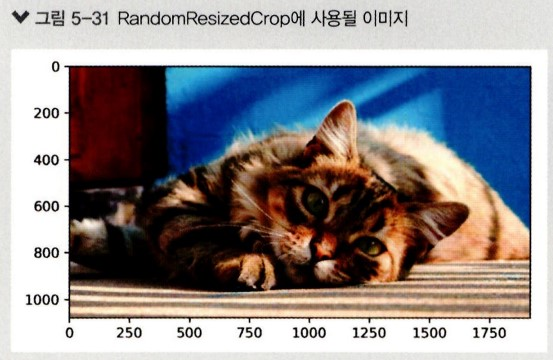

In [29]:
#불러온 이미지에 RandomResizedCrop 적용하기 위한 함수 생성
def show_images(imgs, num_rows, num_cols, scale=2):
  aspect_ratio = imgs[0].shape[0]/imgs[0].shape[1]    #확장할 이미지의 크기 조정
  figsize = (num_cols * scale, num_rows * scale * aspect_ratio)
  _, axes = plt.subplots(num_rows, num_cols, figsize = figsize)
  for i in range(num_rows):
    for j in range(num_cols):
      axes[i][j].imshow(imgs[i * num_cols + j]).asnumpy()
      axes[i][j].axes.get_xaxis().set_visible(False)    #x축 전체를 숨김
      axes[i][j].axes.get_uaxis().set_visible(False)    #y축 전체를 숨김
  plt.subplots_adjust(hspace=0.1, wspace=0)
  return axes

def apply(img, aug, num_rows=2, num_cols=4, scale=3):
  Y = [aug(img) for _ in range(num_rows * num_cols)]    #다양한 샘플을 얻기 위해 여러 번 데이터 확장 적용
  show_images(Y, num_rows, num_cols, scale)

In [ ]:
#RandomResizedCrop이 적용된 이미지를 출력
shape_aug = transforms.RandomResizedCrop(size=(200, 200),
                                        scale=(0.1, 1),
                                        ratio=(0.5, 2))
apply(example_image, shape_aug)

↪
* `size`: 출력할 크기를 200x200으로 조정
* `scale`: 면적 비율을 0.1 ~ 1 (10 ~ 100%) 범위 내에서 무작위로 자름
* `ratio`: 면적의 너비와 높이 비율을 0.5~2 범위 내에서 무작위로 조절

`ratio`를 통해 너비와 비율을 조절한 후 `scale`을 통해 자르고, 최종적으로 출력할 `size`로 조정됨

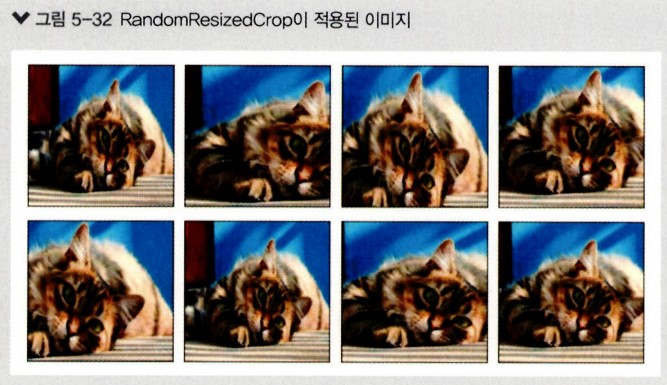

###5.3.1 특성 추출 기법

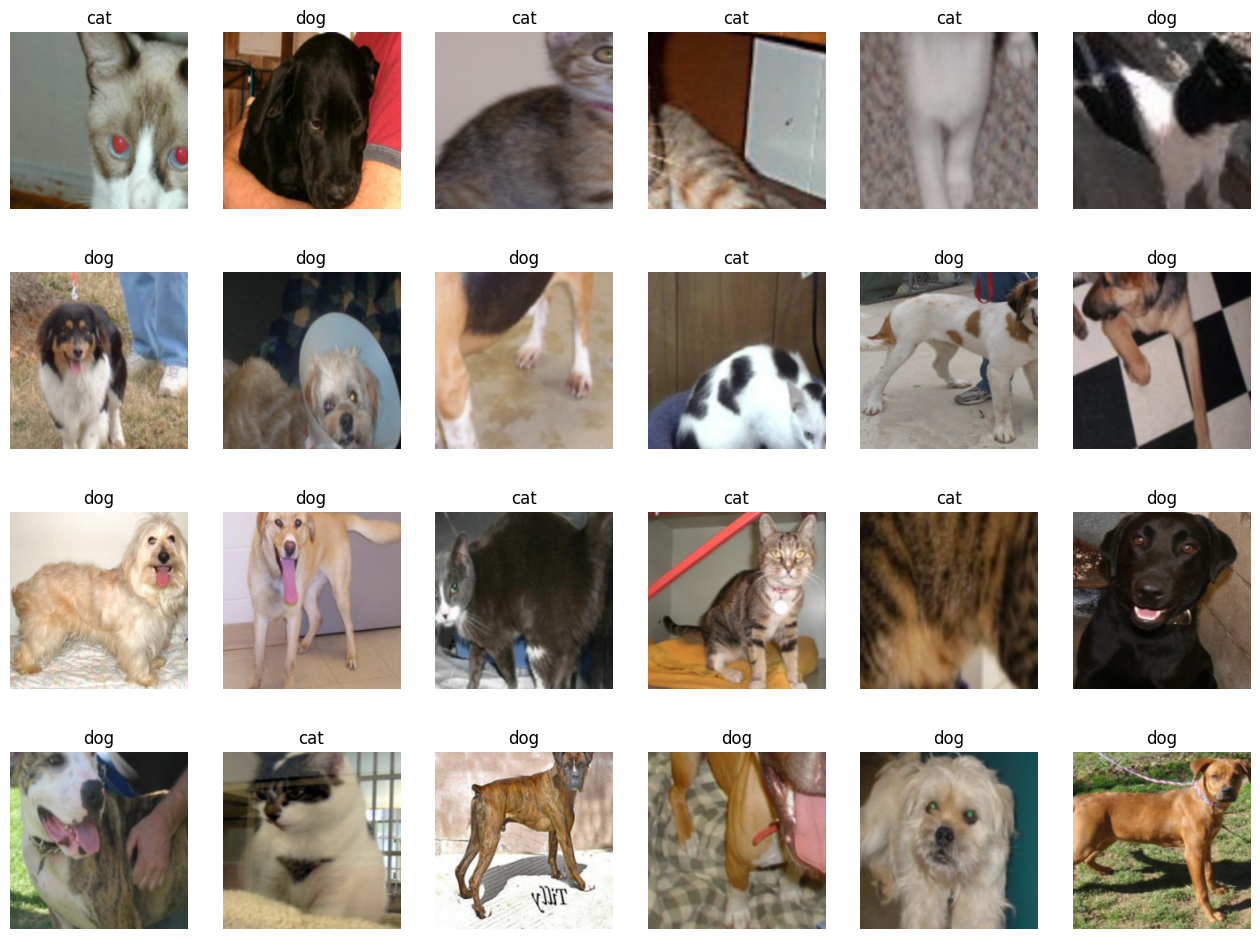

In [38]:
#학습에 사용될 이미지 출력
samples, labels = next(iter(train_loader))    #①
classes = {0:'cat', 1:'dog'}    #개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16, 24))
for i in range(24):   #24개의 이미지 데이터 출력
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()])    #레이블 정보(클래스)를 함께 출력
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))   #②
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

↪
① 반복자(`iterator`, `for` 구문과 같은 효과)를 사용하려면 `iter()`와 `next()`가 필요
* `iter()`는 전달된 데이터의 반복자를 꺼내 반환하며, `next()`는 그 반복자가 다음에 출력해야 할 요소를 반환
* 즉, `iter()`로 반복자를 구하고 그 반복자를 `next()`에 전달하여 차례대로 꺼낼 수 있음
* 앞의 코드에서 반복자는 `train_loader`가 되기 때문에 `train_loader`에서 `samples`와 `labels`의 값을 순차적으로 꺼내서 저장

  ➡ 정리하자면 `train_loader`에서 데이터를 하나씩 꺼내 오겠다는 의미

② `np.transpose`는 행과 열을 바꿈으로써 행렬의 차원을 바꾸어 줌

`print(samples.shape)`을 통해 데이터의 형태를 확인해보면 `torch.Size([32, 3, 224, 224])`가 출력됨

이 상태 그대로(`np.transpose`를 적용하지 않으면) 'Invalid shape (3, 224, 224) for image data'와 같은 오류가 발생

따라서 `np.transpose(sample[i].numpy(), (1,2,0))`을 사용해서 (224, 224, 3)과 같은 형태로 변환한 후 사용해야 함

In [39]:
#예시 - 다음과 같은 변환이 가능
import numpy as np

exam = np.arange(24).reshape(2, 3, 4)
exam

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [40]:
np.transpose(exam, (2, 1, 0))

array([[[ 0, 12],
        [ 4, 16],
        [ 8, 20]],

       [[ 1, 13],
        [ 5, 17],
        [ 9, 21]],

       [[ 2, 14],
        [ 6, 18],
        [10, 22]],

       [[ 3, 15],
        [ 7, 19],
        [11, 23]]])

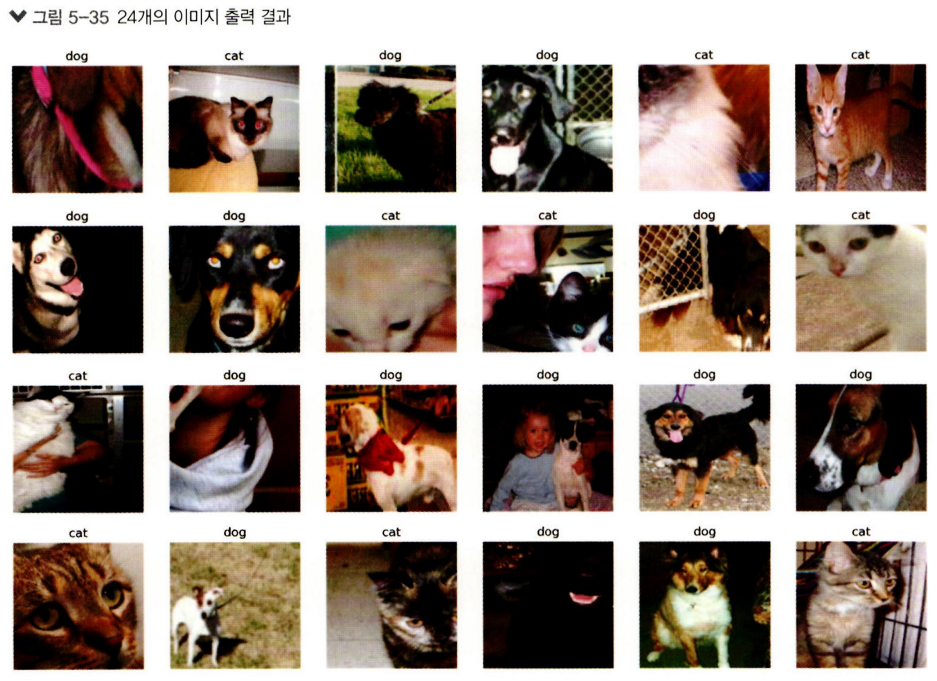

In [41]:
#사전 훈련된 ResNet18 모델 내려받기
resnet18 = models.resnet18(pretrained=True)   #pretrained=True는 사전 학습된 가중치를 사용하겠나느 의미

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


In [42]:
#사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False   #①

set_parameter_requires_grad(resnet18)

↪
① 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타냄
* 즉, 모델의 일부를 고정하고 나머지를 학습하고자 할 때 requires_grad = False로 설정
* 이때 모델의 일부는 합성곱층과 풀링층을 의미

In [43]:
#ResNet18의 마지막 부분에 완전연결층 추가
resnet18.fc = nn.Linear(512, 2)   #2는 클래스가 두 개라는 의미
#추가된 완전연결층은 개와 고양이 클래스를 분류하는 용도로 사용됨

In [44]:
#모델의 파라미터 값 확인
for name, param in resnet18.named_parameters():   #model.named_parameters()는 모델에 접근하여 파라미터 값들을 가져올 때 사용
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0040, -0.0098, -0.0178,  ..., -0.0305,  0.0383, -0.0096],
        [ 0.0420, -0.0229, -0.0270,  ...,  0.0434,  0.0430,  0.0112]])
fc.bias tensor([0.0222, 0.0138])


↪ 파라미터 값들 가져온 결과


In [45]:
#모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True)    #모델의 객체 생성

for param in model.parameters():    #모델의 합성곱층 가중치 고정
  param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters():   #완전연결층은 학습
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()    #손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [50]:
#모델 학습을 위한 함수 생성
def train_model(model, dataloaders, critierion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time()   #컴퓨터의 현재 시각을 구하는 함수
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs):   #에포크(13)만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-' * 10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels, in dataloaders:   #데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad()   #기울기를 0으로 설정
      outputs = model(inputs)   #순전파 학습
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward()   #역전파 학습
      optimizer.step()

      running_loss += loss.item() * inputs.size(0)    #출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data)   #출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장

    epoch_loss = running_loss / len(dataloaders.dataset)    #평균 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset)    #평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/Euron_9기DL/data/catanddog', '{0:0=2d}.pth'.format(epoch)))   #모델 재사용을 위해 저장해 둠
    print()

  time_elapsed = time.time() - since    #실행 시간(학습 시간)을 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history    #모델의 정확도와 오차를 반환

In [51]:
#파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param)    #파라미터 학습 결과를 저장
    print("\t", name)

optimizer = optim.Adam(params_to_update)    #학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


↪ ResNet18에 추가된 완전연결층은 학습을 하도록 설정

학습을 통해 얻어지는 파라미터를 옵티마이저에 전달해서 최종적으로 모델 학습에 사용

`weight`와 `bias` 값들이 업데이트되고 옵티마이저에 전달됨

In [52]:
#모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()   #손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion,
                                              optimizer, device)

Epoch 0/12
----------
Loss: 0.4955 Acc: 0.7688

Epoch 1/12
----------
Loss: 0.3583 Acc: 0.8623

Epoch 2/12
----------
Loss: 0.3145 Acc: 0.8779

Epoch 3/12
----------
Loss: 0.2772 Acc: 0.8909

Epoch 4/12
----------
Loss: 0.2461 Acc: 0.9169

Epoch 5/12
----------
Loss: 0.2742 Acc: 0.8831

Epoch 6/12
----------
Loss: 0.2360 Acc: 0.9117

Epoch 7/12
----------
Loss: 0.2197 Acc: 0.9247

Epoch 8/12
----------
Loss: 0.2151 Acc: 0.9143

Epoch 9/12
----------
Loss: 0.1843 Acc: 0.9221

Epoch 10/12
----------
Loss: 0.2121 Acc: 0.9039

Epoch 11/12
----------
Loss: 0.1832 Acc: 0.9351

Epoch 12/12
----------
Loss: 0.1815 Acc: 0.9325

Training complete in 10m 31s
Best Acc: 0.935065


↪ 모델 훈련을 위해 전달되는 파라미터는 (모델, 학습 데이터, 손실 함수, 옵티마이저, 장치(CPU 혹은 GPU))

훈련 데이터로 학습이 잘 되었으므로 이제 테스트 데이터를 이용해 모델 정확도를 측정

In [66]:
#테스트 데이터 호출 및 전처리
test_path = '/content/drive/MyDrive/Euron_9기DL/data/catanddog/test'

transform = transforms.Compose(
                [
                    transforms.Resize(224),
                    transforms.CenterCrop(224),
                    transforms.ToTensor()
])
test_dataset = torchvision.datasets.ImageFolder(
                root=test_path,
                transform=transform
)
test_loader = torch.utils.data.DataLoader(
                test_dataset,
                batch_size=32,
                num_workers=1,
                shuffle=True
)

print(len(test_dataset))

98


In [86]:
#테스트 데이터 평가 함수 생성
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('/content/drive/MyDrive/Euron_9기DL/data/catanddog/' + '*.pth')   #①
  saved_models.sort()   #불러온 .pth 파일들을 정렬
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:    #테스트 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad():   #autograd를 사용하지 않겠다는 의미
        outputs = model(inputs)   #데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs.data, 1)   #②
      preds[preds >= 0.5] = 1   #torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
      preds[preds < 0.5] = 0    #torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds.eq(labels.cpu()).int().sum()    #③

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)    #테스트 데이터의 정확도 계산
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history    #계산된 정확도 반환

↪
① `glob`은 현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용
* '../chap05/data/catanddog/' 경로에서 pth 확장자를 갖는 파일 가져오라는 의미
* pth라는 확장자 갖는 파일은 훈련 데이터로 모델을 훈련시킬 때 생성된 파일

② `torch.max`는 주어진 텐서 배열의 최댓값이 들어있는 index를 반환하는 함수
* Ex) `y_pred = [[0.2,0.7,0.8,0.4]]`라는 배열에 `torch.max(y_pred.data, 1)`을 적용한다고 가정할 때 `[0.2,0.7,0.8,0.4]`의 최댓값은 0.8이 되며 그 인덱스는 2이므로 최종적으로 반환되는 값은 2가 됨

③ `preds.eq(labels)`는 preds 배열과 labels가 일치하는지 검사하는 용도로 사용됨
* 뒤에 사용된 `.sum()`은 모델의 예측 결과와 정답(레이블)이 일치하는 것들의 개수 합을 숫자로 출력

In [87]:
#테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/Euron_9기DL/data/catanddog/00.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/01.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/02.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/03.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/04.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/05.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/06.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/07.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/08.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/09.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/10.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/11.pth', '/content/drive/MyDrive/Euron_9기DL/data/catanddog/12.pth']
Loading model /content/drive/MyDrive/Euron_9기DL/data/catanddog/00.pth
Acc: 0.9184

Loading model /content/drive/MyDrive/Euron_9기DL/data/catanddog/01.pth
Acc: 0.9082

Loading model /content/drive/MyDrive/Eu

↪ 테스트 데이터도 높은 정확도 보임

만약 모델의 네트워크를 개발자가 직접 구현하고 최적의 파라미터 값 찾는다면 꽤 오랜 시간이 소요될 것이지만, 사전 훈련된 모델을 사용한다면 손쉽게 모델을 학습시킬 수 있음

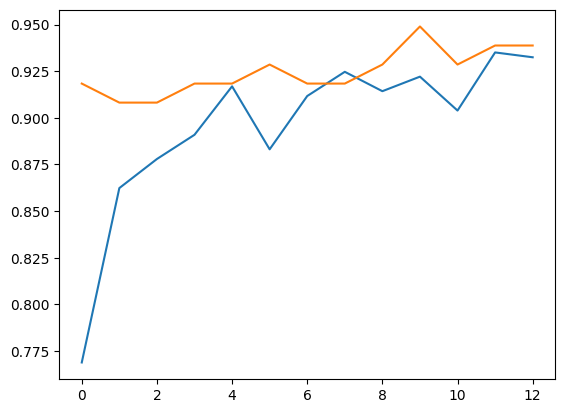

In [88]:
#훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

↪ 훈련과 테스트 데이터 모두 에포크가 진행될수록 정확도가 높아지면서 100%에 가까워짐

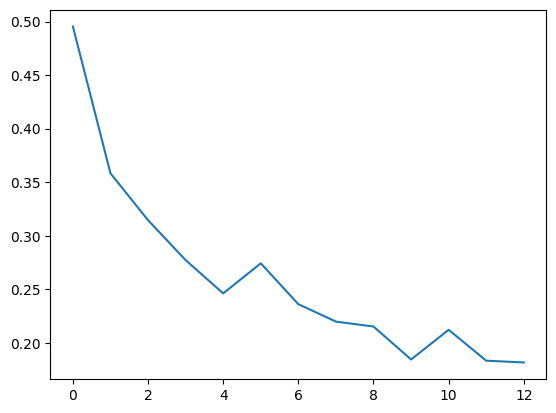

In [89]:
#훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

↪ 에포크가 진행될수록 오차가 낮아지고 있기 때문에 학습이 잘되었다 할 수 있음

실제로 데이터를 잘 예측하는지 살펴보기

In [90]:
#예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy()   #①
  image = image.transpose(1, 2, 0)
  image = image * (np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0, 1)    #②
  return image

↪
① `tensor.clone()`은 기존 텐서의 내용을 복사한 텐서를생성하겠다는 의미, `detach()`는 기존 텐서에서 기울기가 전파되지 않는 텐서
➡ `tensor.clone().detach()`는 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지는 않겠다는 의미

② `clip()`은 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용
* `image.clip(0, 1)`은 `image` 데이터를 0과 1 사이의 값으로 제한하겠다는 의미

In [91]:
#clip() 사용 예시
import numpy as np
exam = np.array([-1.8, -1.2, -0.7, 0.0, 0.8, 1.4, 1.9])
print(exam)
print(np.clip(exam, -0.5, 0.5))

[-1.8 -1.2 -0.7  0.   0.8  1.4  1.9]
[-0.5 -0.5 -0.5  0.   0.5  0.5  0.5]


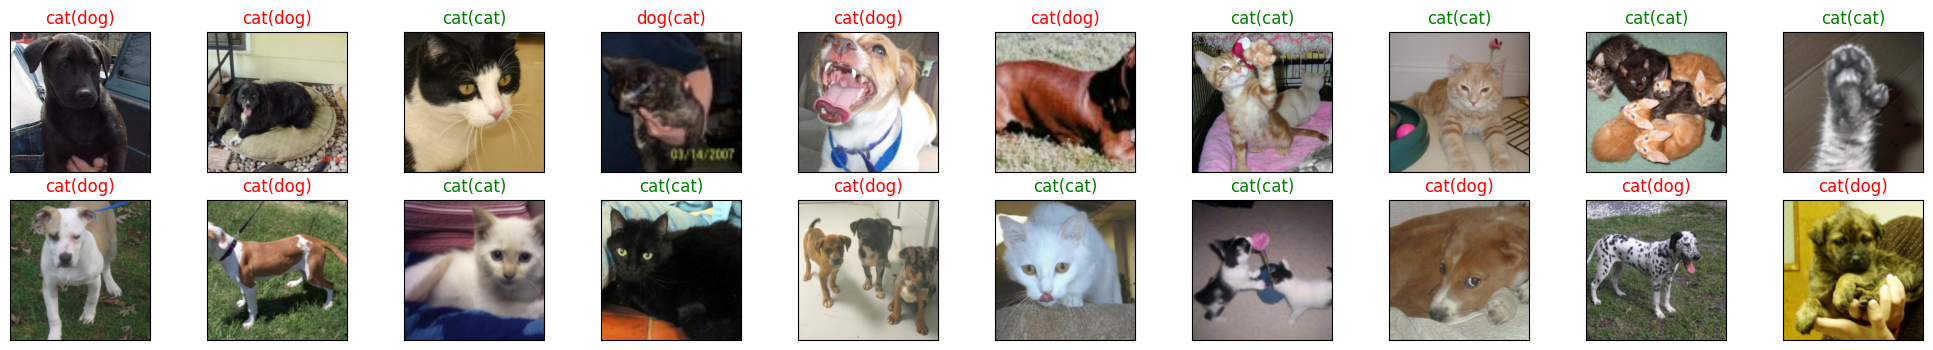

<Figure size 640x480 with 0 Axes>

In [94]:
#개와 고양이 예측 결과 출력
classes = {0:'cat', 1:'dog'}    #개와 고양이 두 개에 대한 레이블

dataiter = iter(test_loader)    #테스트 데이터셋 가져오기
images, labels = next(dataiter)    #테스트 데이터셋에서 이미지와 레이블을 분리해서 가져오기
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])    #①
  plt.imshow(im_convert(images[idx]))   #이미지 출력을 위해 im_convert 함수를 적용
  a.set_title(classes[labels[i].item()])
  ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
             color=("green" if preds[idx]==labels[idx] else "red"))    #②
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)    #③

↪ ① `add_subplot`은 한 화면에 여러 개의 이미지를 담기 위해 사용
* 첫 번째 파라미터: 행의 수를 의미, 여기서는 이미지를 두 줄로 출력
*두 번째 파라미터: 열의 수를 의미, 여기서는 한 줄에 열 개의 이미지를 출력
* 세 번째 파라미터: 인덱스를 의미, 행과 열을 기준으로 순차적으로 이미지를 출력
* 네 번째 파라미터: 틱(tick)을 삭제하겠다는 의미

② `classes[preds[idx].item()]`은 `preds[idx].item()` 값이 classes로 정의된 '0'과 '1' 중 어떤 값을 갖는지 판별하겠다는 의미
* `classes[preds[idx].item()]` 값이 0이면 고양이, 1이면 개로 출력됨

③Figure 안에서 서브플롯(subplot)의 위치를 조정할 때 사용
* left, bottom, right, top으로 이미지 위치를 조정
* `hspace`와 `wspace`를 사용해 서브플롯 사이의 간격(너비와 높이의 비율)을 조정 가능

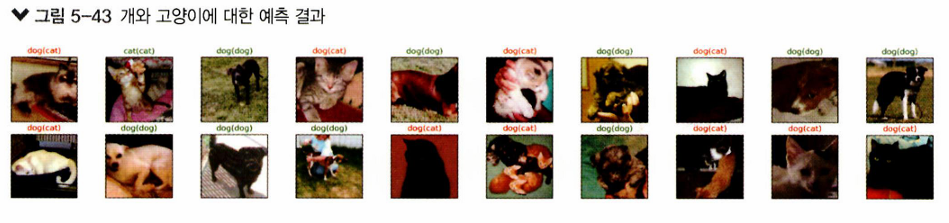

↪ 초록색은 개와 고양이를 정확히 예측한 것, 빨간색은 예측이 잘못되었음을 의미

예측이 정확하지 않은 것을 확인할 수 있음

훈련 데이터를 더 늘리고 에포크 횟수도 늘려보면서 개선 가능

###5.4.1 특성 맵 시각화

In [95]:
#PIL 라이브러리 설치
!pip install pillow

↪ 이미지 분석 및 처리를 쉽게 할 수 있도록 도와주는 라이브러리인 PIL(Python Image Library)을 설치

PIL은 다양한 이미지 파일 형식을 지원하며, 강력한 이미지 처리와 그래픽 기능을 제공하는 이미지 프로세싱 라이브러리

In [125]:
#필요한 라이브러리 호출
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [143]:
#설명 가능한 네트워크 생성(12개의 합성곱층과 두 개의 완전연결층으로 구성, 렐루 활성화함수 사용)
class XAI(torch.nn.Module):
  def __init__(self, num_classes=2):
    super(XAI, self).__init__()
    self.features = nn.Sequential(
      nn.Conv2d(3, 64, kernel_size=3, bias=False),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),   #inplace=True는 기존의 데이터를 연상의 결괏값으로 대체하는 것을 의미
      nn.Dropout(0.3),
      nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),

      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(0.4),
      nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
      nn.Linear(512, 512, bias=False),
      nn.Dropout(0.5),
      nn.BatchNorm1d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(0.5),
      nn.Linear(512, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = x.view(-1, 512)
    x = self.classifier(x)
    return F.log_softmax(x)   #①

↪ ① 로그 소프트맥스(`log_softmax()`)는 신경망 말단의 결괏값들을 확률 개념으로 해석하기 위해 소프트맥스 함수의 결과에 log 값을 취한 연산
* 소프트맥스가 아닌 로그 소프트맥스를 사용하는 이유는 소프트맥스는 기울기 소멸 문제에 취약하기 때문

In [144]:
#생성된 모델을 model = XAI()로 객체화
model = XAI()   #model이라는 이름의 객체를 생성
model.to(device)    #model을 장치(CPU 혹은 GPU)에 할당
model.eval()    #테스트 데이터에 대한 모델 평가 용도로 사용

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

* 특성 맵의 시각화에 대해 살펴보기 위해 특성 맵의 결과를 확인할 수 있는 함수를 정의
* 특성 맵은 합성곱층을 입력 이미지와 필터를 연산하여 얻은 결과이므로 합성곱층에서 입력과 출력을 알 수 있다면 특성 맵에 대한 값들을 확인할 수 있단 의미

In [145]:
#특성 맵을 확인하기 위한 클래스 정의
class LayerActivations:
  features = []
  def __init__(self, model, layer_num):
    self.hook = model[layer_num].register_forward_hook(self.hook_fn)   #①

  def hook_fn(self, module, input, output):
    self.features = output.detach().numpy()

  def remove(self):   #hook 삭제
    self.hook.remove()

↪ ① 파이토치는 매 계층마다 print 문을 사용하지 않더라도 hook 기능을 사용하여 각 계층의 활성화 함수 및 기울기 값을 확인할 수 있음
* 따라서 register_forward_hook의 목적은 순전파 중에 각 네트워크 모듈의 입력 및 출력을 가져오는 것

In [109]:
#예시 코드
import torch
x = torch.Tensor([0,1,2,3]).requires_grad_()
y = torch.Tensor([4,5,6,7]).requires_grad_()
w = torch.Tensor([1,2,3,4]).requires_grad_()
z = x + y;
o = w.matmul(z)
o.backward()
print(x.grad, y.grad, z.grad, w.grad, o.grad)

tensor([1., 2., 3., 4.]) tensor([1., 2., 3., 4.]) None tensor([ 4.,  6.,  8., 10.]) None


/tmp/ipython-input-2701639746.py:9: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  print(x.grad, y.grad, z.grad, w.grad, o.grad)


↪ 코드에서 `o`와` z`는 특정한 값으로 정의되지 않은 중간변수(계산 결과에 따라 값이 달라질 수 있는 변수)

파이토치는 이러한 변수에 대해서는 기울기 값을 저장하지 않음

이와 같은 중간 변수에 대해 `z.register_hook(hook_fn)`을 사용하면 기울기 값을 알 수 있음

➡ 이와 같이 `hook`을 이용하면 중간 결괏값들을 확인할 수 있음

torch.Size([1, 3, 100, 100])


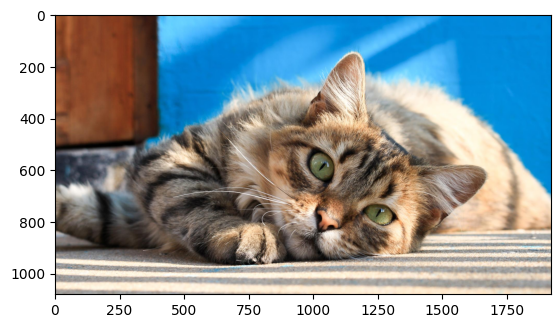

In [146]:
#이미지 호출
img = cv2.imread("/content/drive/MyDrive/Euron_9기DL/data/cat.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)   #①
img = ToTensor()(img).unsqueeze(0)    #②
print(img.shape)

↪ ① `cv2.resize`는 이미지 크기를 변경할 때 사용
* 첫 번째 파라미터: 변경할 이미지 파일
* 두 번째 파라미터: 변경될 이미지 크기를 (너비, 높이)로 지정
* `interpolation`: 보간법
  * 이미지 크기를 변경할 경우 변형된 이미지의 픽셀을 추정해서 값 할당해야 함
  * 이미지 비율을 변경하면 존재하지 않는 영역에 새로운 픽셀 값을 매핑하거나 존재하는 픽셀들을 압축해서 새로운 값을 할당해야 함
  * 이러한 상황을 피하고자 이미지상에 존재하는 픽셀 데이터 (xi, yi)들에 대해 근사 함수 f(xi, yi)를 적용해서 새로운 픽셀 값을 구하는 것이 보간법
  ➡ 즉, 추정해야 하는 픽셀을 보간법을 이용하여 값을 할당

② `ToTensor()(img).unsqueeze(0)`에서 사용된 `unsqueeze()`는 1차원 데이터를 생성하는 함수
* 이미지 데이터를 텐서로 변환하고, 그 변환된 데이터를 1차원으로 변경하겠다는 의미

In [111]:
#예시 코드
import torch

x1 = torch.rand(3, 10, 64)
x2 = x1.unsqueeze(dim=0)    #[3,10,64]->[1,3,10,64]
print(x2.shape)
print('------------')
x3 = x1.unsqueeze(dim=1)    #[3,10,64]->[3,1,10,64]
print(x3.shape)

torch.Size([1, 3, 10, 64])
------------
torch.Size([3, 1, 10, 64])


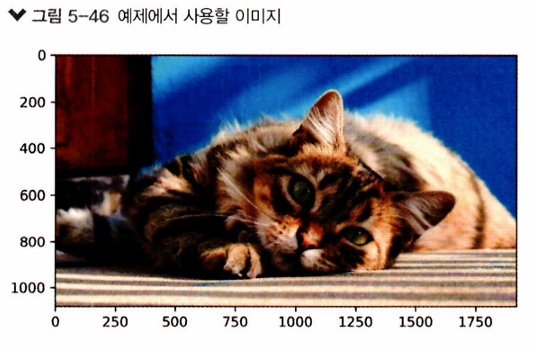

In [147]:
#(0): Conv2d 특성 맵 확인
result = LayerActivations(model.features, 0)    #0번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

/tmp/ipython-input-2043491251.py:76: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)   #①


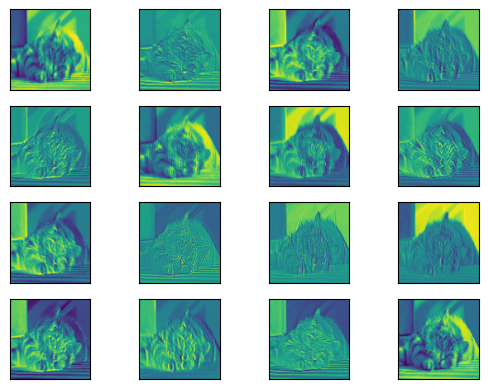

<Figure size 1200x800 with 0 Axes>

In [148]:
#특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

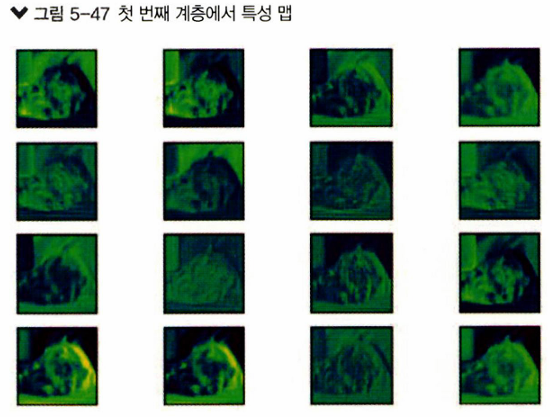

↪ 입력층과 가까운 계층으로 입력 이미지의 형태가 많이 유지되고 있음

학습이 진행될수록 이미지의 변화를 확인할 수 있도록 20번째, 40번째 계층에 대한 특성 맵도 살펴보기

In [149]:
#20번째 계층에 대한 특성 맵
result = LayerActivations(model.features, 20)    #20번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

/tmp/ipython-input-2043491251.py:76: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)   #①


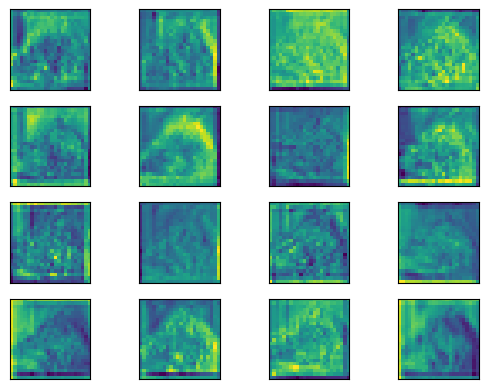

<Figure size 1200x800 with 0 Axes>

In [150]:
#특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

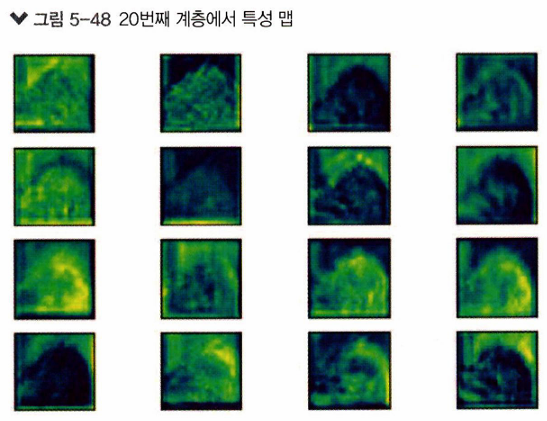

↪ 기존 고양이 이미지의 형태는 찾아볼 수 없게 됨

In [151]:
#40번째 계층에 대한 특성 맵
result = LayerActivations(model.features, 40)    #40번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

/tmp/ipython-input-2043491251.py:76: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)   #①


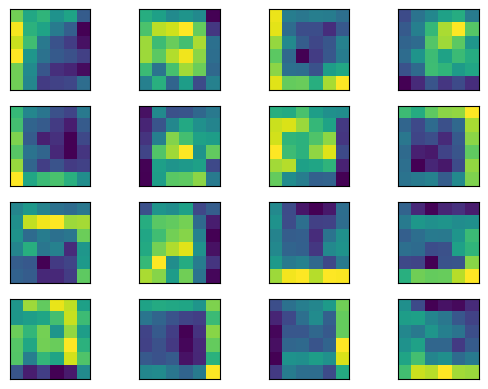

<Figure size 1200x800 with 0 Axes>

In [152]:
#특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

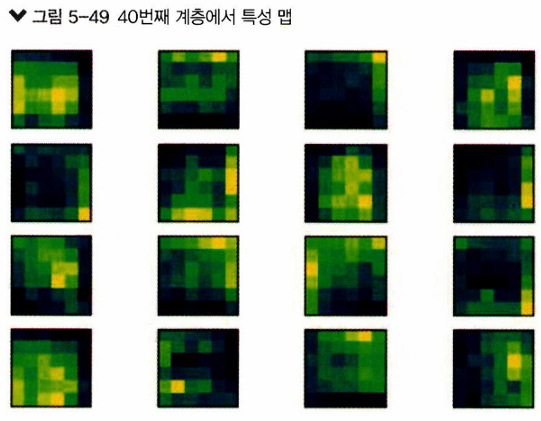

↪ 원래 입력 이미지에 대한 형태는 전혀 찾아볼 수 없음

즉, 출력층에 가까울수록 원래 형태는 찾아볼 수 없고, 이미지 특징들만 전달되는 것을 확인할 수 있음